First 5 Rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  

Dataset Shape:
(150, 6)

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Statistical Summary:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333    

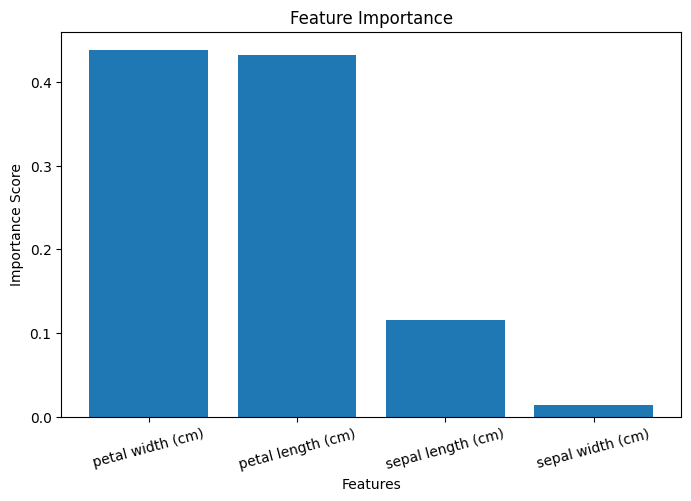


Example Prediction:
Predicted Class: setosa


In [1]:
# Advanced Machine Learning Classification Project - Iris Dataset

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# -----------------------------
# Load Dataset
# -----------------------------
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add target column
df['target'] = iris.target

# Add target names
df['species'] = df['target'].apply(lambda x: iris.target_names[x])

# -----------------------------
# Dataset Exploration
# -----------------------------
print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

print("\nClass Distribution:")
print(df['species'].value_counts())

# -----------------------------
# Features and Labels
# -----------------------------
X = iris.data
y = iris.target

# -----------------------------
# Feature Scaling
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# Split Dataset
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# Build Advanced Model
# -----------------------------
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

# Train Model
model.fit(X_train, y_train)

# -----------------------------
# Predictions
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# Model Evaluation
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:")
print(f"{accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# -----------------------------
# Feature Importance
# -----------------------------
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': iris.feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)

# -----------------------------
# Visualization
# -----------------------------
plt.figure(figsize=(8,5))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=15)

plt.show()

# -----------------------------
# Example Prediction
# -----------------------------
sample = [X_test[0]]

prediction = model.predict(sample)

print("\nExample Prediction:")
print("Predicted Class:", iris.target_names[prediction[0]])